In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
col = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = pd.read_csv('../data/magic04.data', names=col)
df['class'] = (df['class'] == 'g').astype(int)
df['class'].unique

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
19015    0
19016    0
19017    0
19018    0
19019    0
Name: class, Length: 19020, dtype: int64>

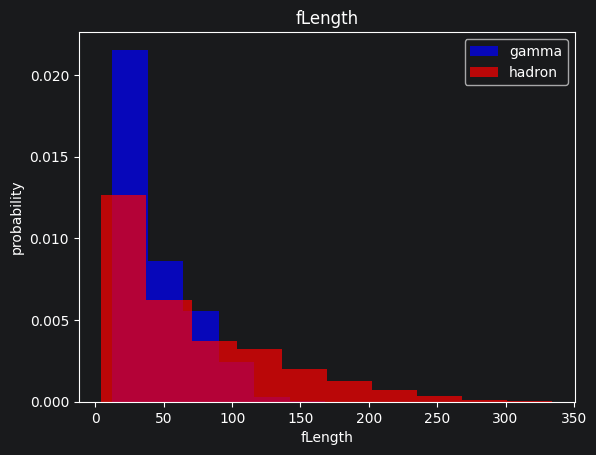

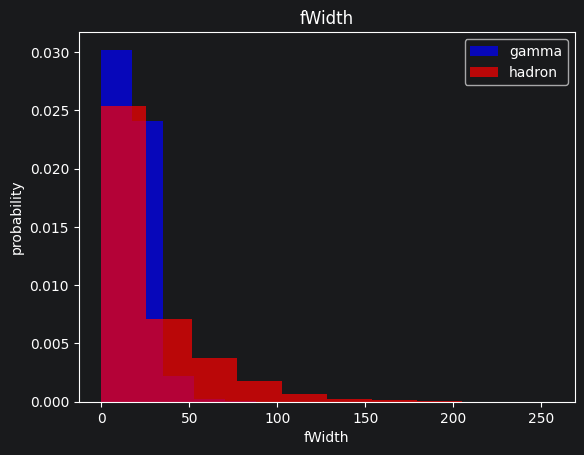

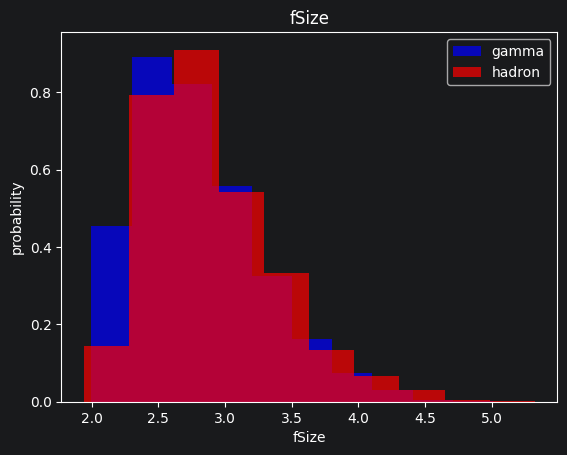

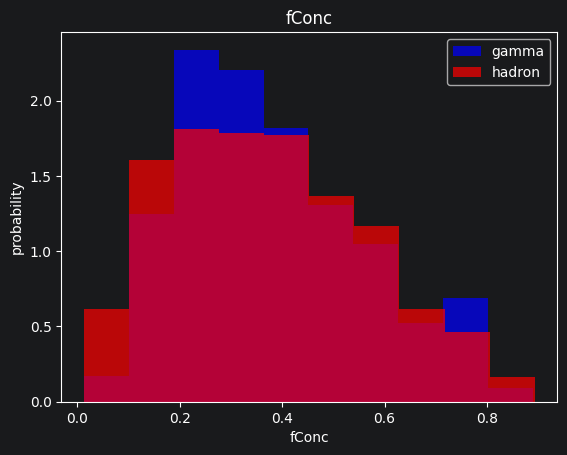

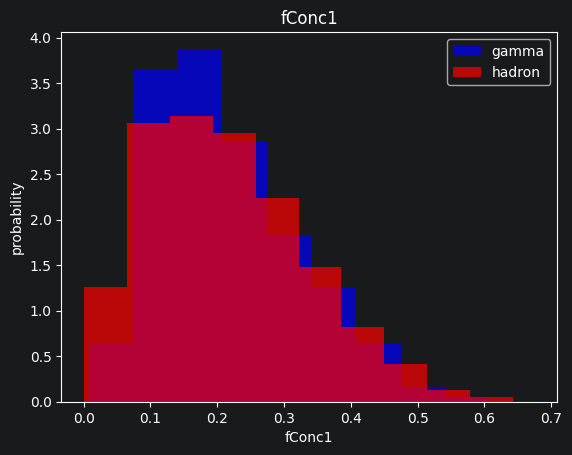

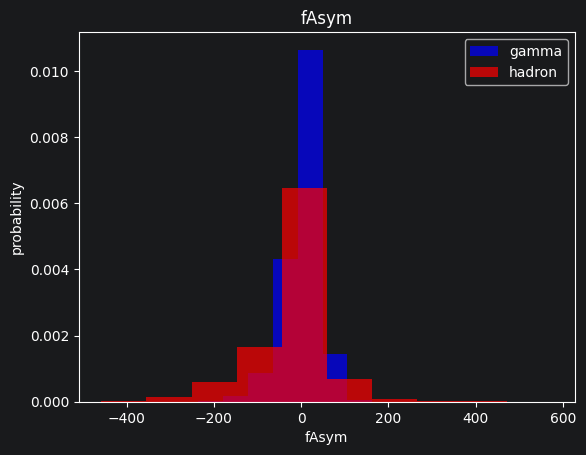

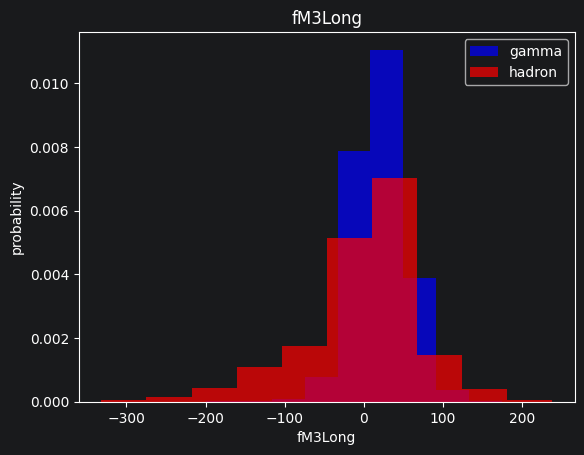

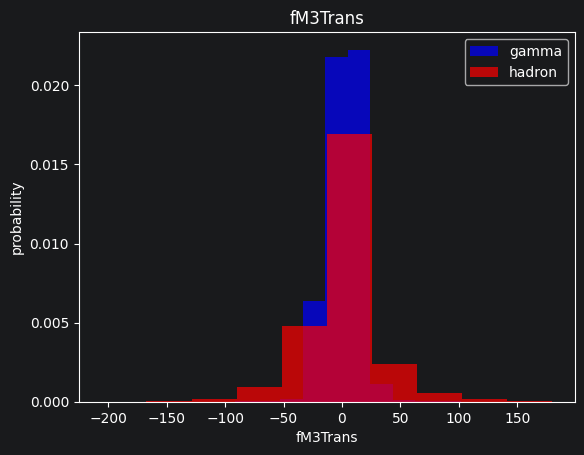

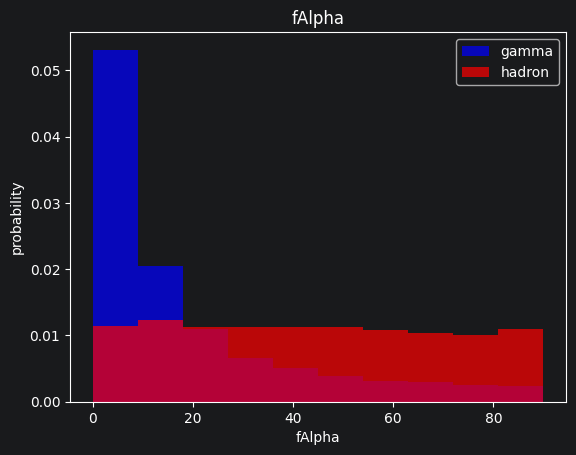

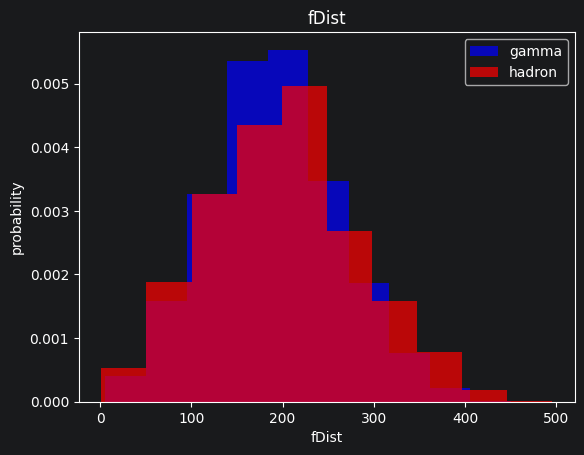

In [3]:
for label in col[:-1]: #plot probability that a entry is gamma or hadron given values from the other categories
    plt.hist(df[df['class']==1][label], color = 'blue', label = 'gamma', alpha = 0.7, density=True)# density = true normalizes each data point
    plt.hist(df[df['class']==0][label], color = 'red', label = 'hadron', alpha = 0.7, density=True)
    plt.title(label)
    plt.ylabel('probability')
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [4]:
shuffled_df = df.sample(frac=1, random_state=42)

train, valid, test = (
    shuffled_df.iloc[:int(0.6 * len(shuffled_df))],
    shuffled_df.iloc[int(0.6 * len(shuffled_df)):int(0.8 * len(shuffled_df))],
    shuffled_df.iloc[int(0.8 * len(shuffled_df)):]
)

In [5]:
def scale_dataset(dataframe, oversample=False):# we want to rescale our values because if some categories have larger numbers than others, some models can incorrectly assume they are more important
    X = dataframe[dataframe.columns[:-1]].values # creates a 2d array with the values of every column other than "class"
    y = dataframe[dataframe.columns[-1]].values # creates an array with the class values (0 and 1)

    scaler = StandardScaler()
    X = scaler.fit_transform(X) #scale the values of X so they become usable

    if oversample:
        ros = RandomOverSampler()
        X,y = ros.fit_resample(X, y) # there are fewer samples where class = 0, so oversample the amount of samples where class = 0.
                                     # That means randomly duplicate samples where class = 0
                                     # until the amount of samples where class = 0 is the same as the amount of samples where class =1

    data = np.hstack((X,np.reshape(y, (-1,1))))#giving -1 is telling np to infer what the length should be, same as saying len(y)
                                               #hstack puts X and y next to each other. So the nparray has the X entries, and then the y entries to the right
                                               #hstack requires both entries to be of the same dimensions, so we're basically making y a 2d array where the second dimension is 1

    return data, X, y

In [6]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)#don't oversample for the valid and test datasets. We want actual data for those.
test, X_test, y_test = scale_dataset(test, oversample=False)

# K-nearest neighbors

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred = knn_model.predict(X_test)

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.73      0.73      1331
           1       0.86      0.85      0.85      2473

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



# Naive Bayes

In [11]:
from sklearn.naive_bayes import GaussianNB

In [12]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [13]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1331
           1       0.73      0.89      0.80      2473

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.71      0.72      0.69      3804



# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
lg_model = LogisticRegression()
lg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1331
           1       0.84      0.81      0.82      2473

    accuracy                           0.78      3804
   macro avg       0.75      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



# SVM

In [17]:
from sklearn.svm import SVC

In [18]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [19]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79      1331
           1       0.89      0.89      0.89      2473

    accuracy                           0.85      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.85      0.85      0.85      3804



# Neural Net

In [20]:
import tensorflow as tf

In [40]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.grid(True)

    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('accuracy')
    ax2.grid(True)
    plt.show()


In [29]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.Input(shape=(10,)),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    history = nn_model.fit(
    x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0
    )
    return nn_model, history

In [27]:
history = nn_model.fit(
    X_train, y_train,
    epochs=100, batch_size=32, validation_split=0.2, verbose=0
)

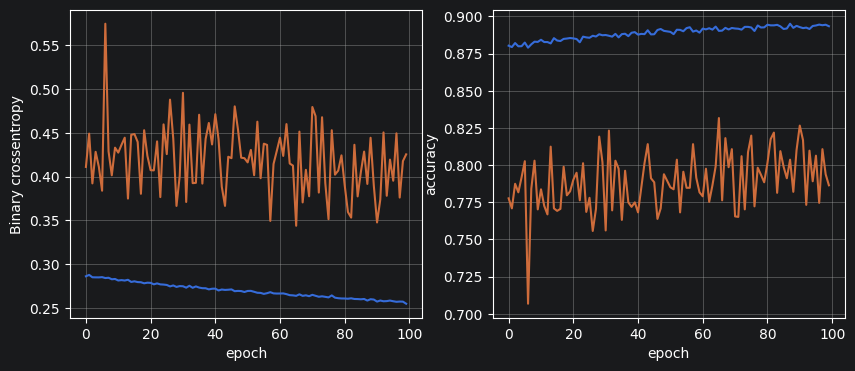

In [38]:
plot_history(history)

16 nodes, dropout 0, lr 0.01, batch_size 32


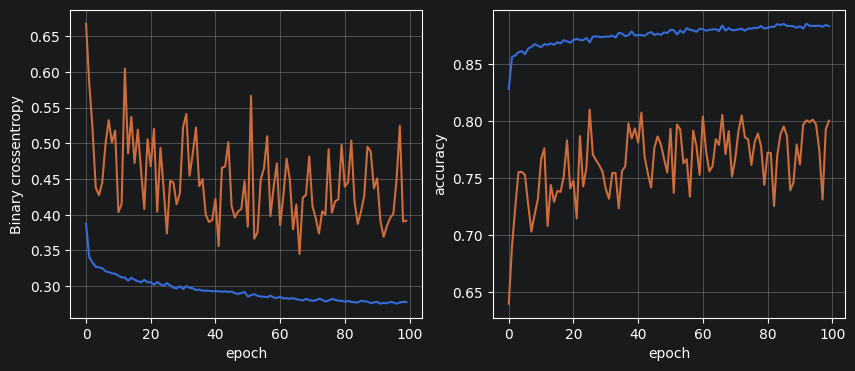

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.8670 - loss: 0.3483
16 nodes, dropout 0, lr 0.01, batch_size 64


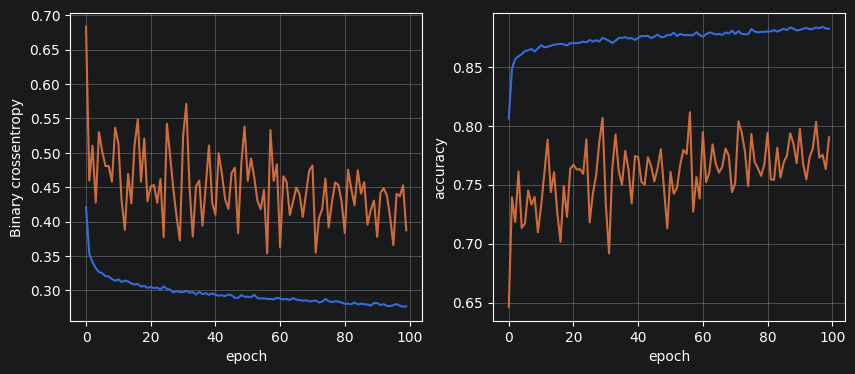

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - accuracy: 0.8701 - loss: 0.3210
16 nodes, dropout 0, lr 0.01, batch_size 128


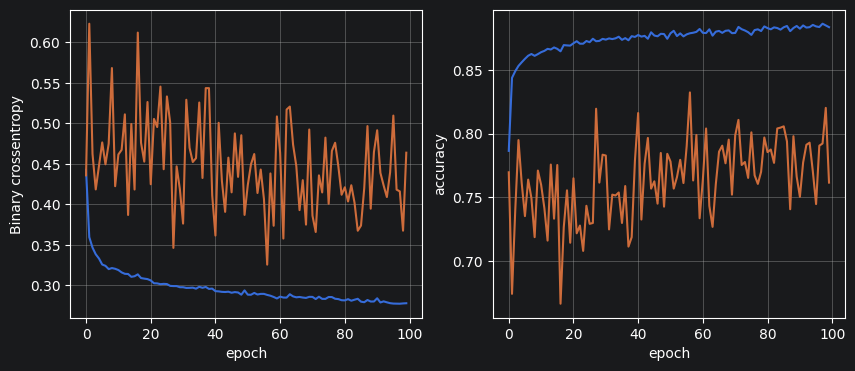

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.8759 - loss: 0.3135
16 nodes, dropout 0, lr 0.005, batch_size 32


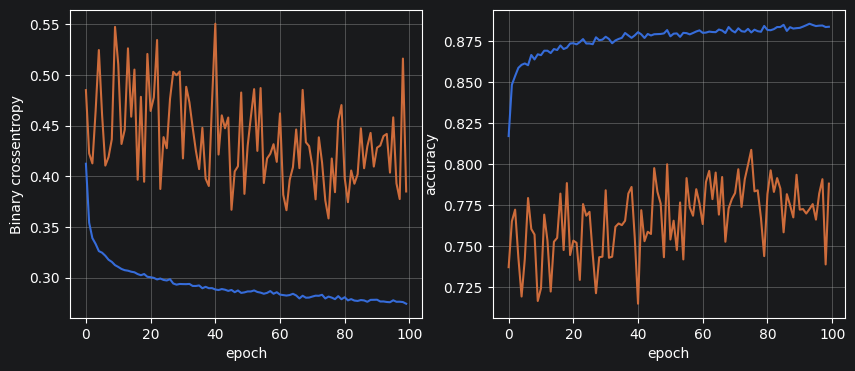

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.8751 - loss: 0.3256
16 nodes, dropout 0, lr 0.005, batch_size 64


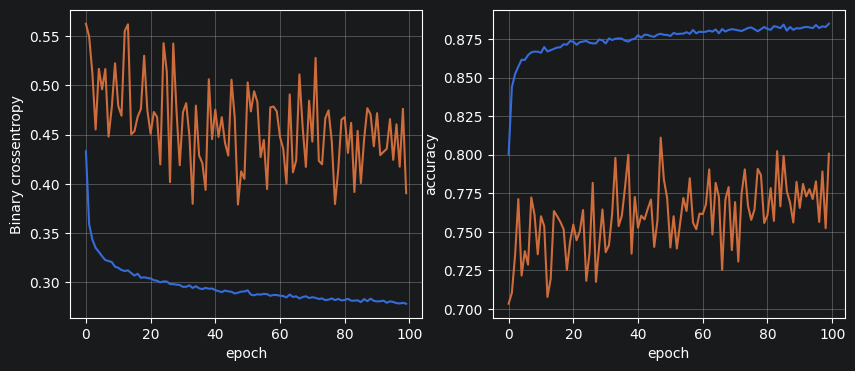

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.8696 - loss: 0.3193
16 nodes, dropout 0, lr 0.005, batch_size 128


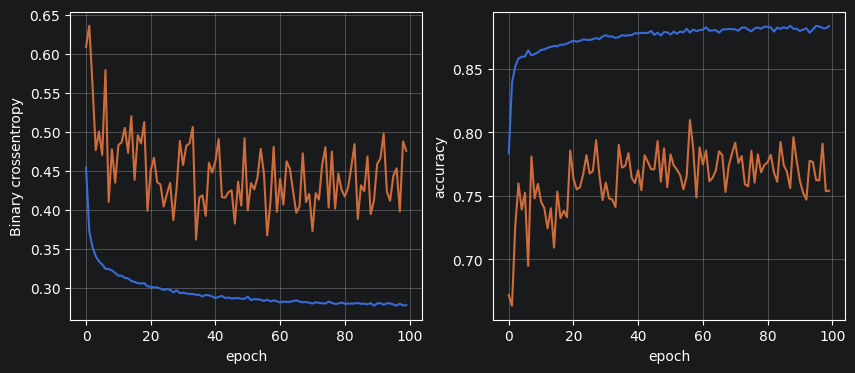

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.8736 - loss: 0.3175
16 nodes, dropout 0, lr 0.001, batch_size 32


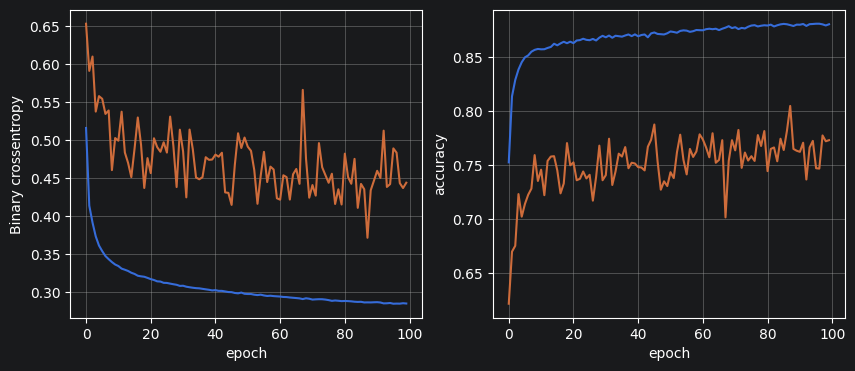

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.8741 - loss: 0.3058
16 nodes, dropout 0, lr 0.001, batch_size 64


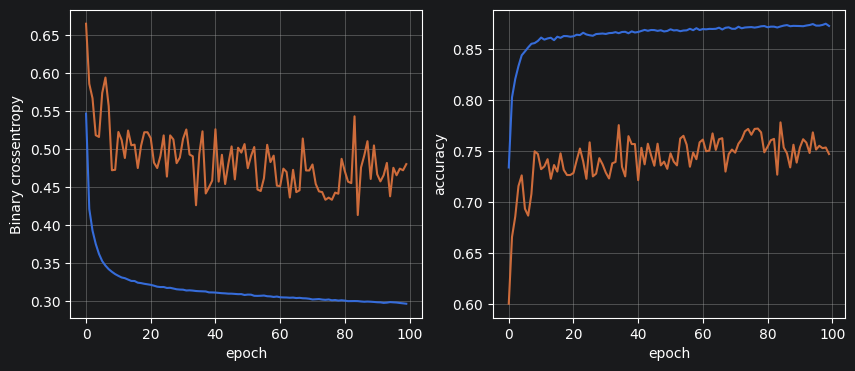

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - accuracy: 0.8728 - loss: 0.3136
16 nodes, dropout 0, lr 0.001, batch_size 128


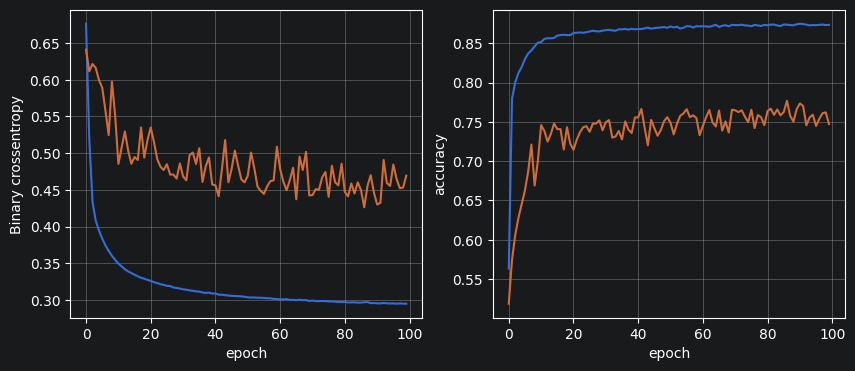

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.8778 - loss: 0.3091
16 nodes, dropout 0.2, lr 0.01, batch_size 32


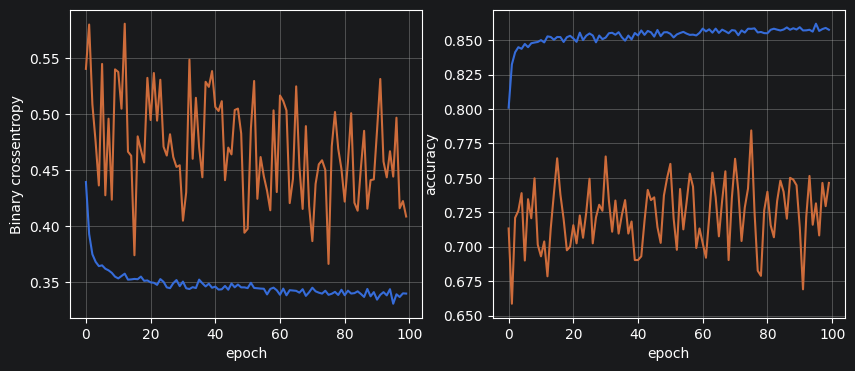

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - accuracy: 0.8665 - loss: 0.3252
16 nodes, dropout 0.2, lr 0.01, batch_size 64


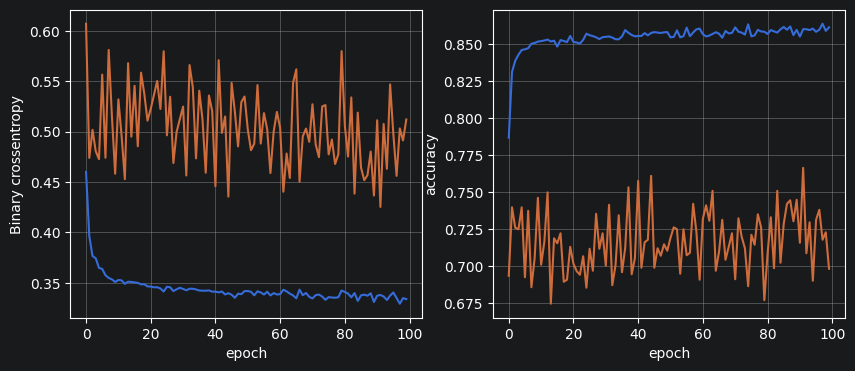

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.8659 - loss: 0.3204
16 nodes, dropout 0.2, lr 0.01, batch_size 128


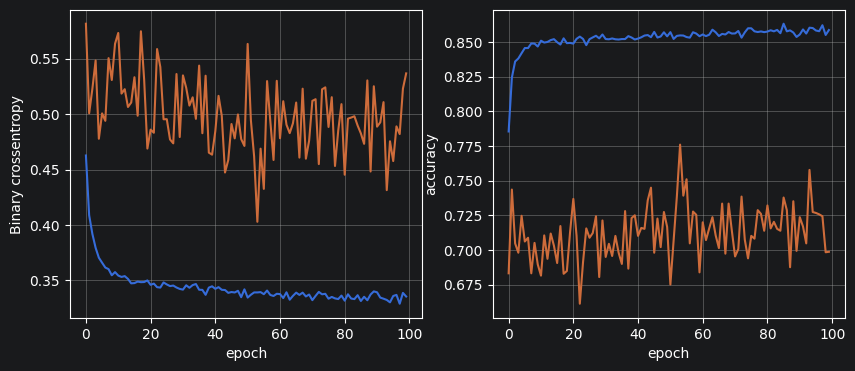

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.8707 - loss: 0.3156
16 nodes, dropout 0.2, lr 0.005, batch_size 32


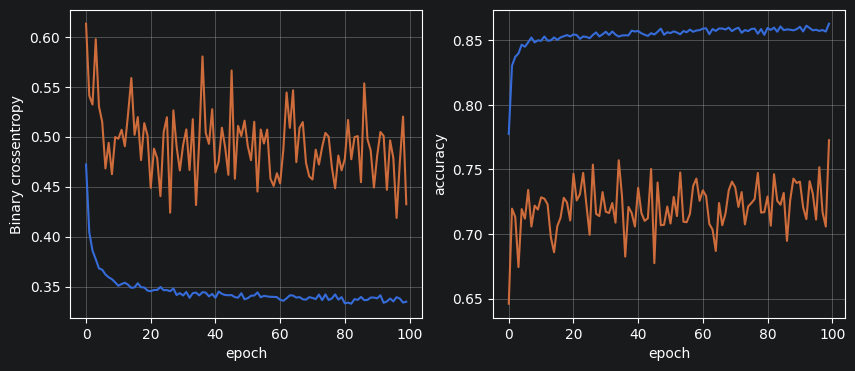

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - accuracy: 0.8678 - loss: 0.3192
16 nodes, dropout 0.2, lr 0.005, batch_size 64


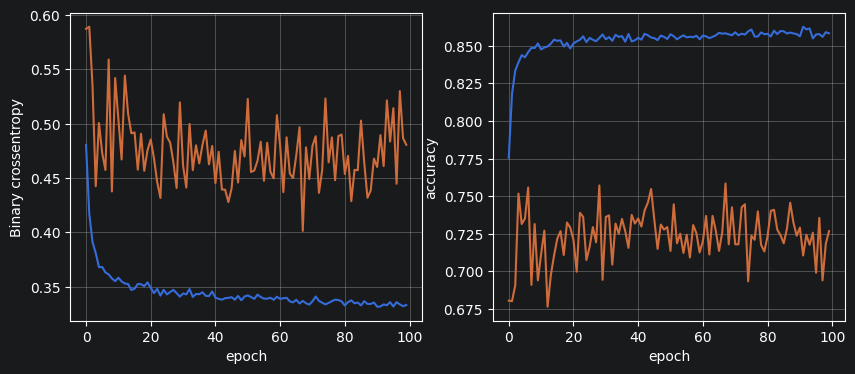

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.8720 - loss: 0.3108
16 nodes, dropout 0.2, lr 0.005, batch_size 128


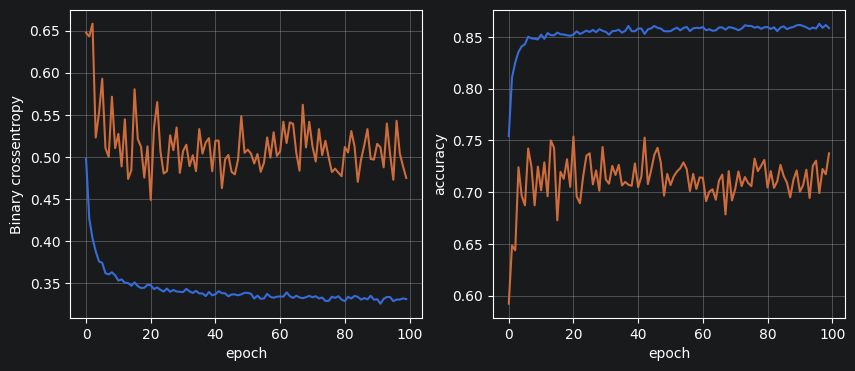

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.8696 - loss: 0.3119
16 nodes, dropout 0.2, lr 0.001, batch_size 32


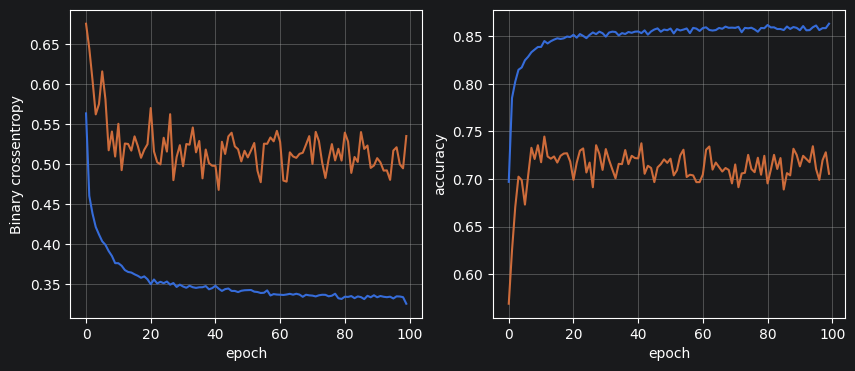

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.8649 - loss: 0.3148
16 nodes, dropout 0.2, lr 0.001, batch_size 64


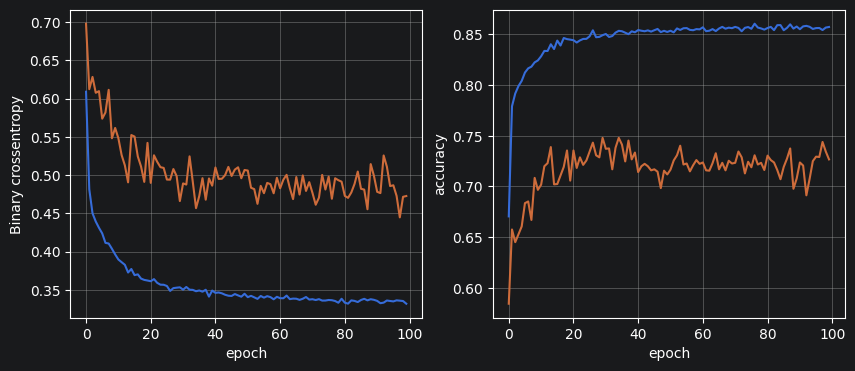

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.8691 - loss: 0.3111
16 nodes, dropout 0.2, lr 0.001, batch_size 128


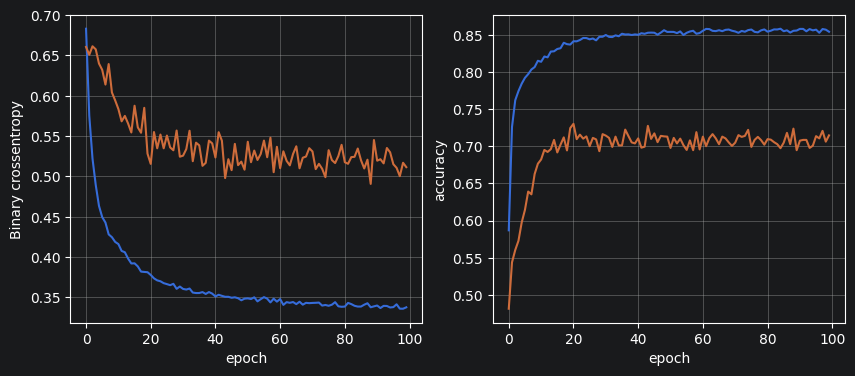

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.8704 - loss: 0.3183
23 nodes, dropout 0, lr 0.01, batch_size 32


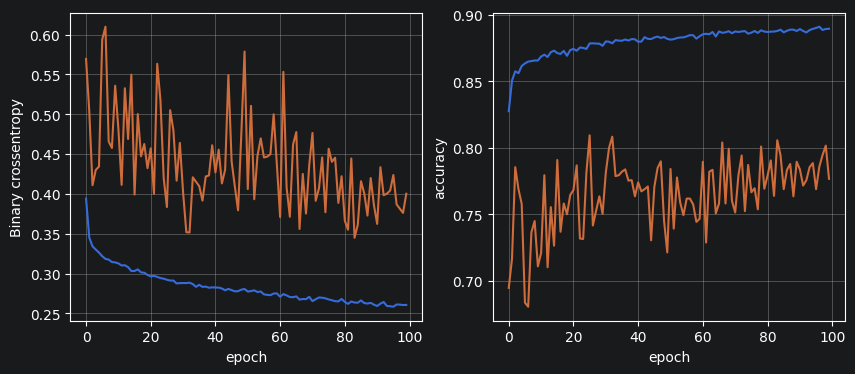

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.8741 - loss: 0.3268
23 nodes, dropout 0, lr 0.01, batch_size 64


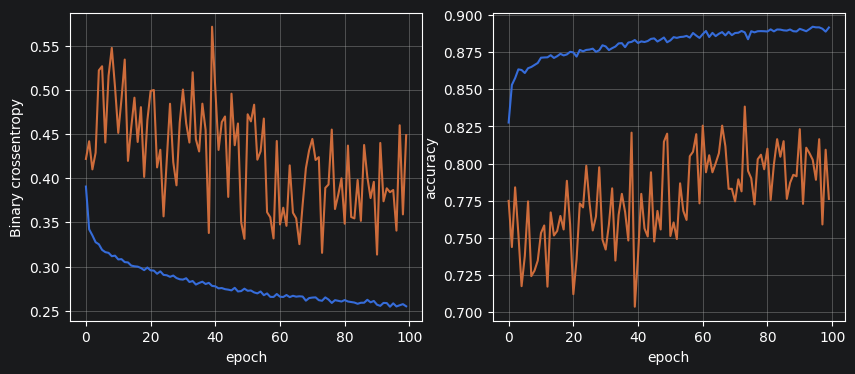

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - accuracy: 0.8693 - loss: 0.3378
23 nodes, dropout 0, lr 0.01, batch_size 128


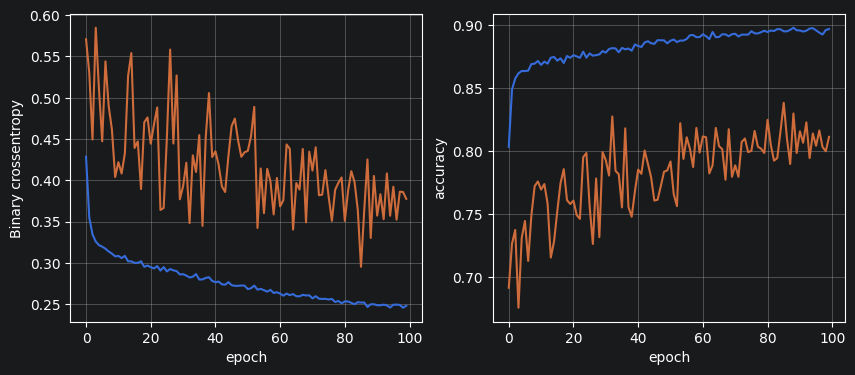

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.8693 - loss: 0.3293
23 nodes, dropout 0, lr 0.005, batch_size 32


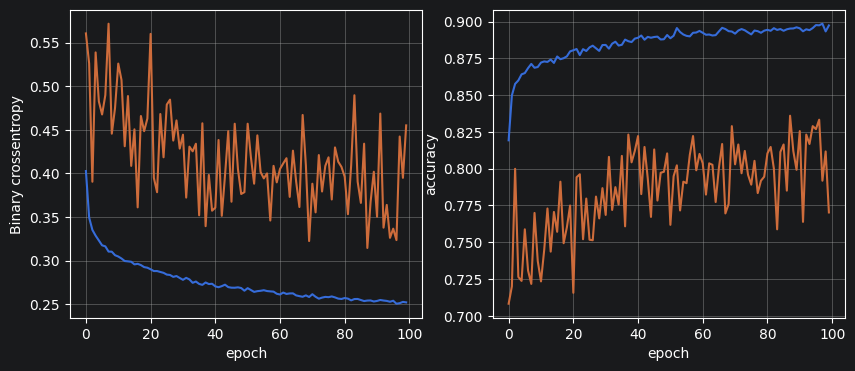

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.8720 - loss: 0.3418
23 nodes, dropout 0, lr 0.005, batch_size 64


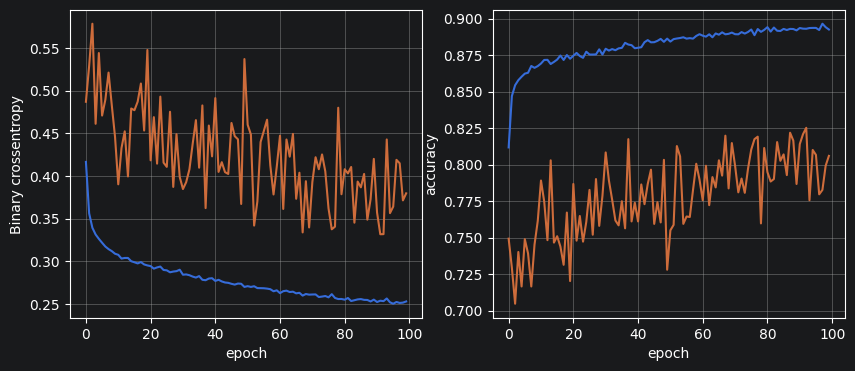

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8701 - loss: 0.3247
23 nodes, dropout 0, lr 0.005, batch_size 128


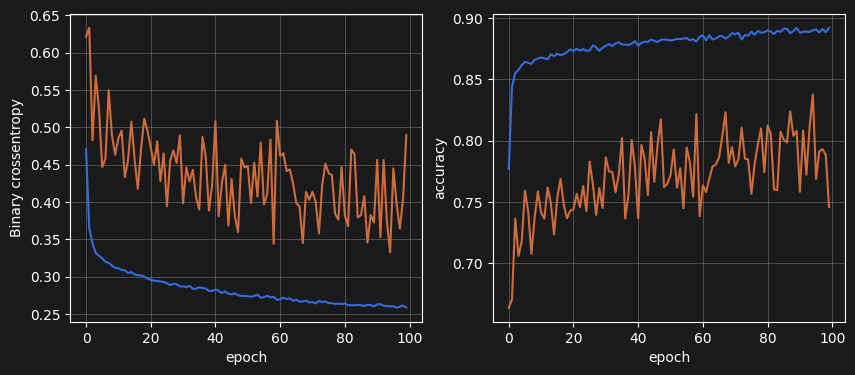

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8717 - loss: 0.3284
23 nodes, dropout 0, lr 0.001, batch_size 32


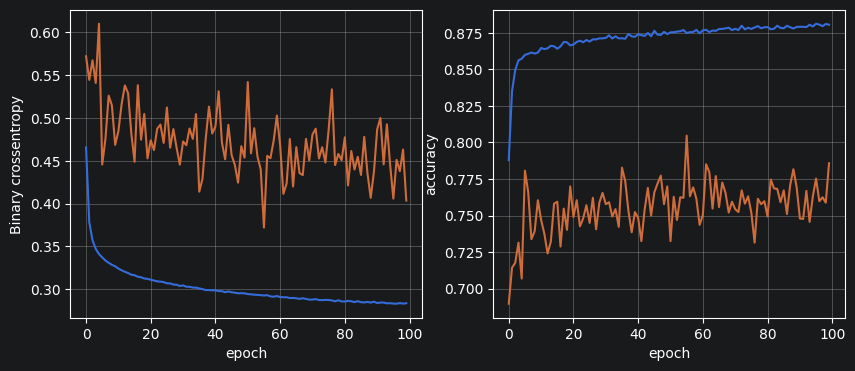

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - accuracy: 0.8749 - loss: 0.3123
23 nodes, dropout 0, lr 0.001, batch_size 64


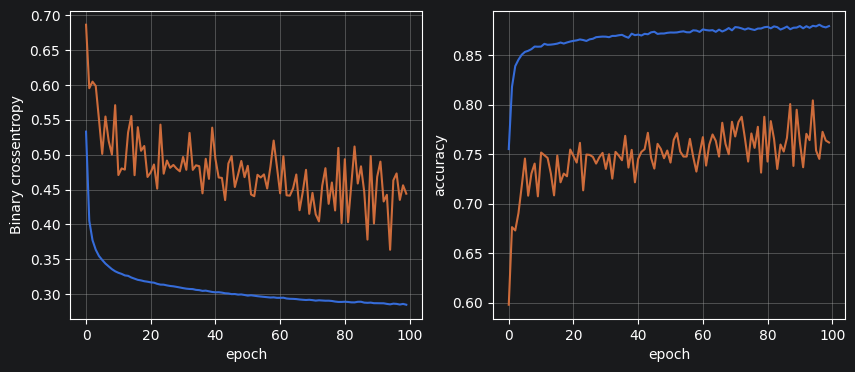

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.8741 - loss: 0.3086
23 nodes, dropout 0, lr 0.001, batch_size 128


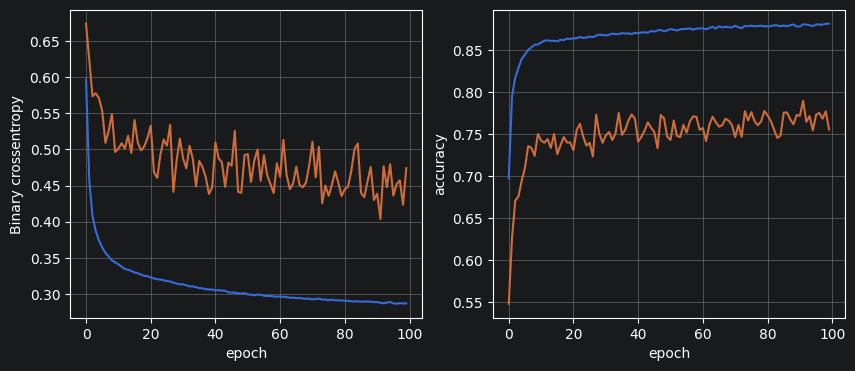

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - accuracy: 0.8759 - loss: 0.3070
23 nodes, dropout 0.2, lr 0.01, batch_size 32


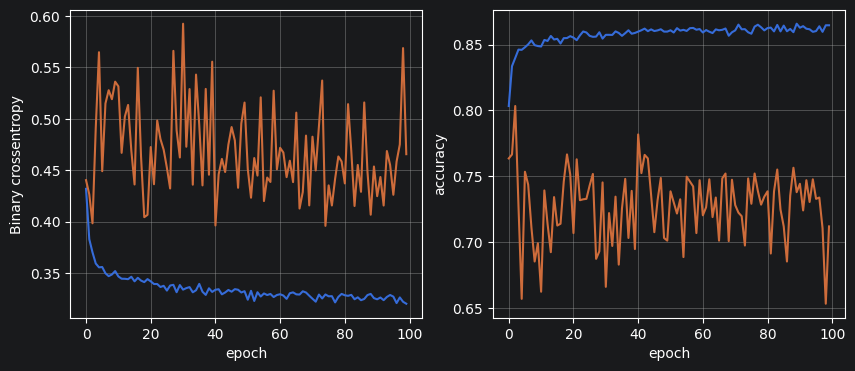

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - accuracy: 0.8693 - loss: 0.3236
23 nodes, dropout 0.2, lr 0.01, batch_size 64


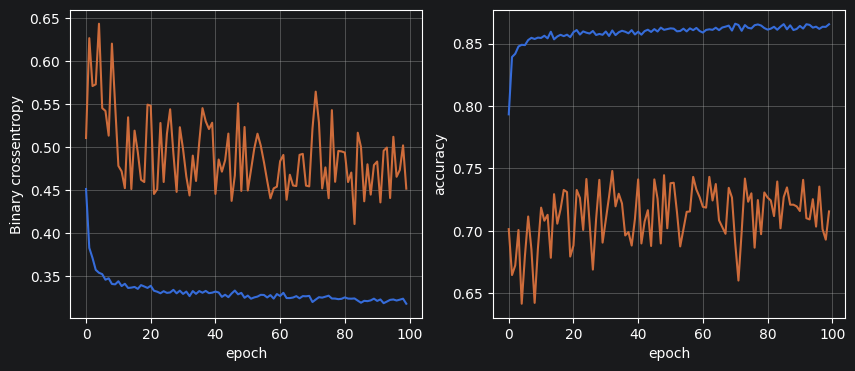

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.8728 - loss: 0.3116
23 nodes, dropout 0.2, lr 0.01, batch_size 128


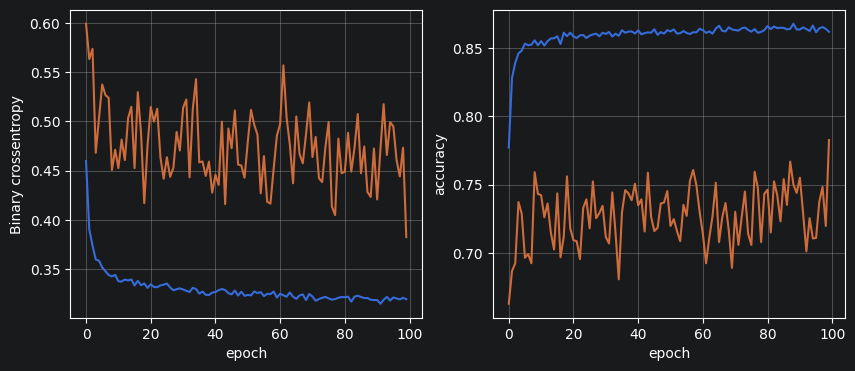

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.8730 - loss: 0.3101
23 nodes, dropout 0.2, lr 0.005, batch_size 32


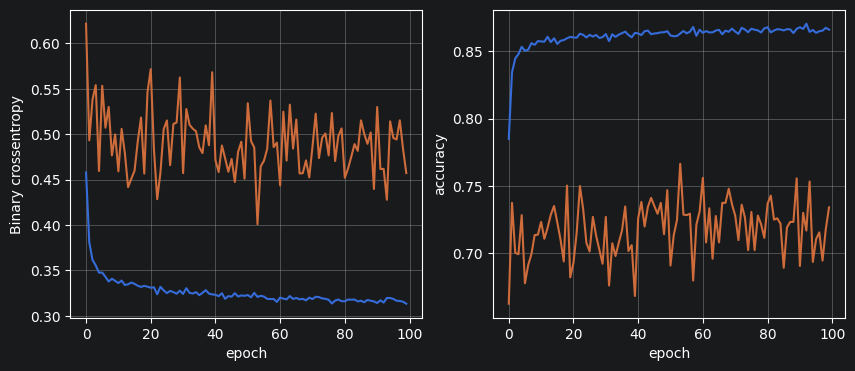

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8733 - loss: 0.3088
23 nodes, dropout 0.2, lr 0.005, batch_size 64


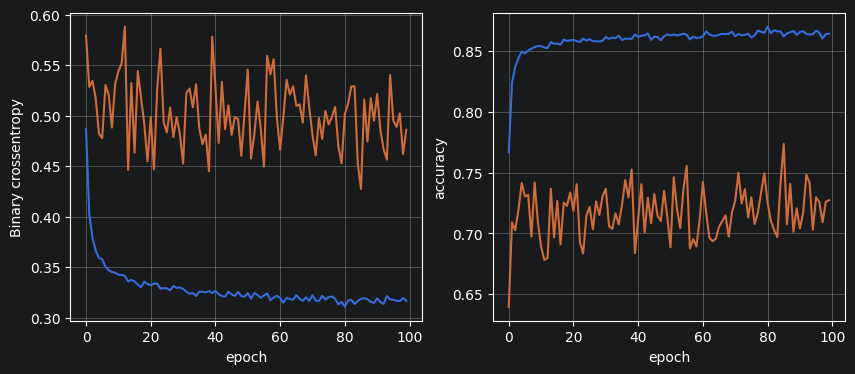

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.8712 - loss: 0.3115
23 nodes, dropout 0.2, lr 0.005, batch_size 128


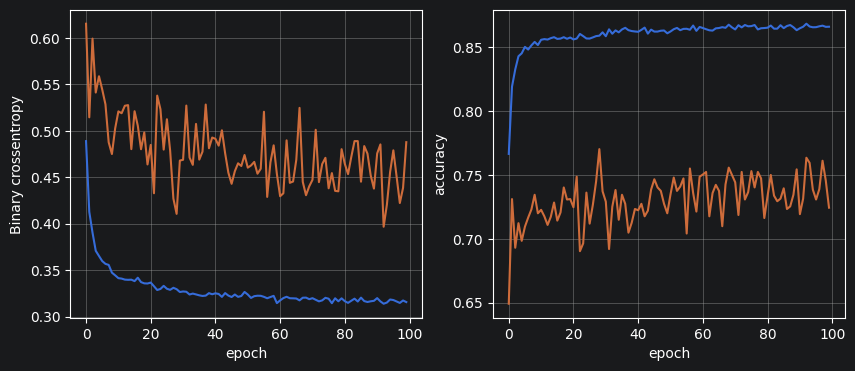

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.8699 - loss: 0.3087
23 nodes, dropout 0.2, lr 0.001, batch_size 32


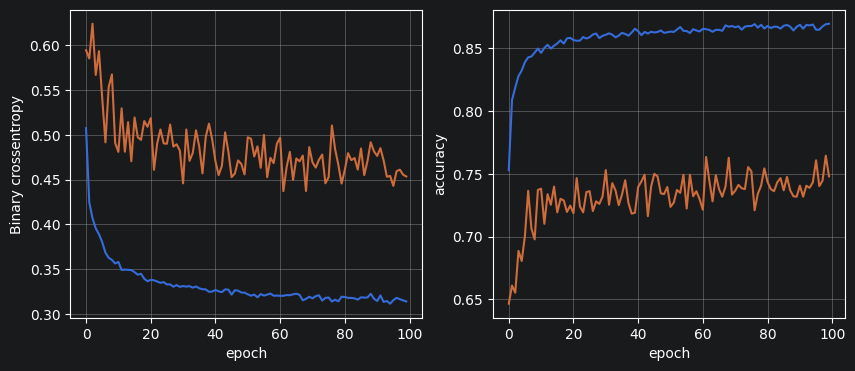

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.8728 - loss: 0.3053
23 nodes, dropout 0.2, lr 0.001, batch_size 64


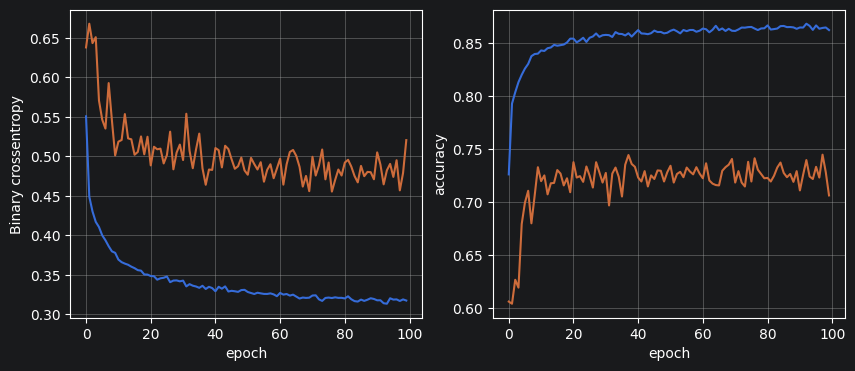

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - accuracy: 0.8696 - loss: 0.3091
23 nodes, dropout 0.2, lr 0.001, batch_size 128


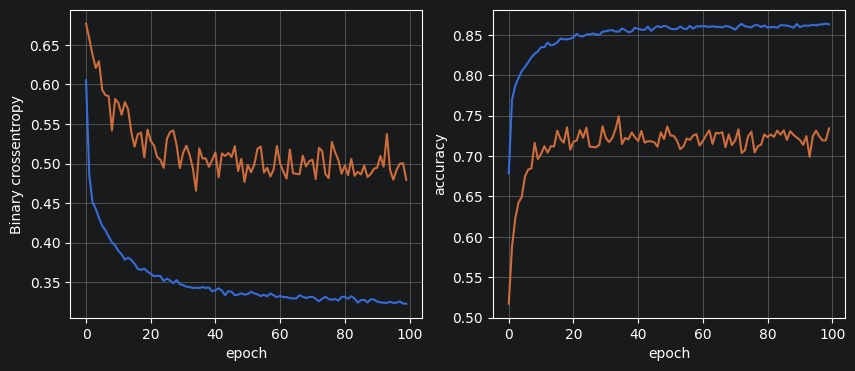

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - accuracy: 0.8699 - loss: 0.3085
64 nodes, dropout 0, lr 0.01, batch_size 32


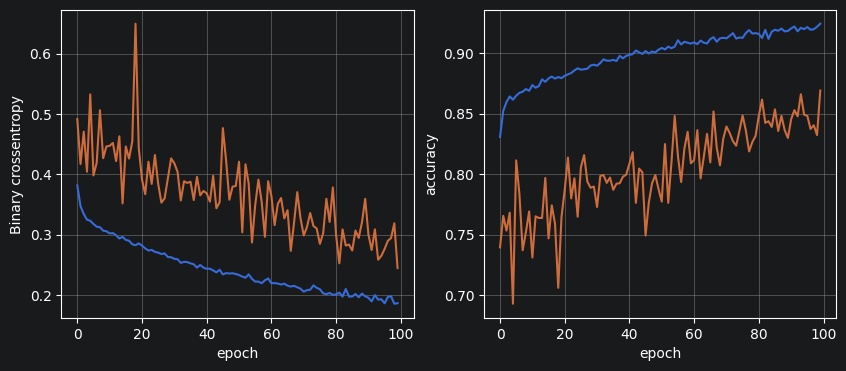

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - accuracy: 0.8607 - loss: 0.5832
64 nodes, dropout 0, lr 0.01, batch_size 64


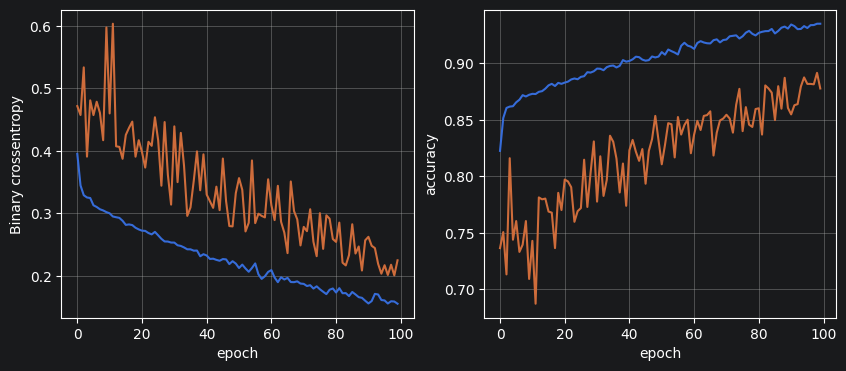

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8570 - loss: 0.6694
64 nodes, dropout 0, lr 0.01, batch_size 128


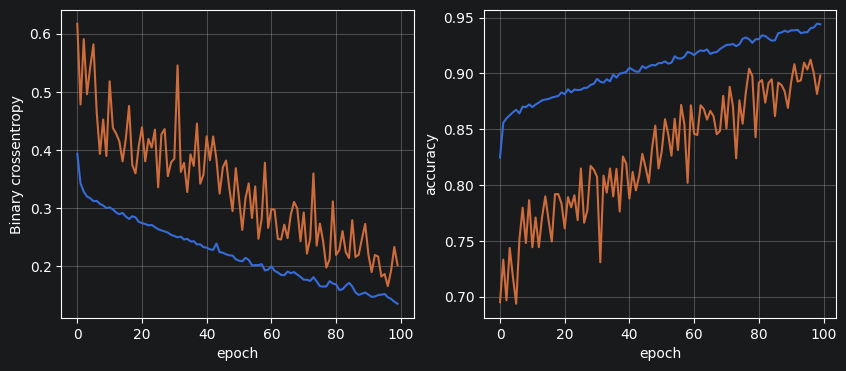

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8615 - loss: 0.6247
64 nodes, dropout 0, lr 0.005, batch_size 32


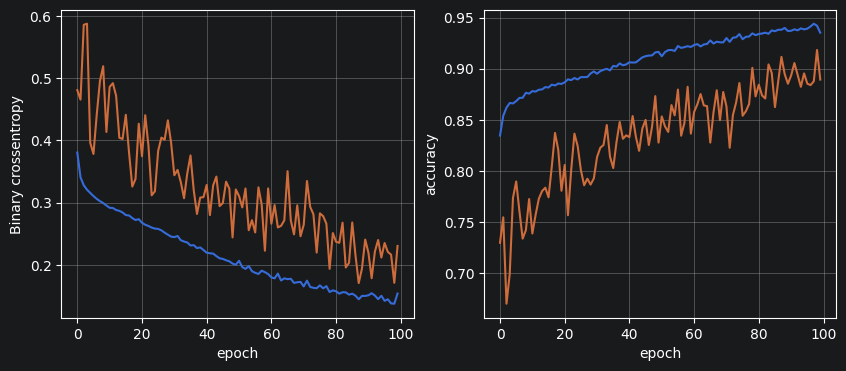

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - accuracy: 0.8646 - loss: 0.6444
64 nodes, dropout 0, lr 0.005, batch_size 64


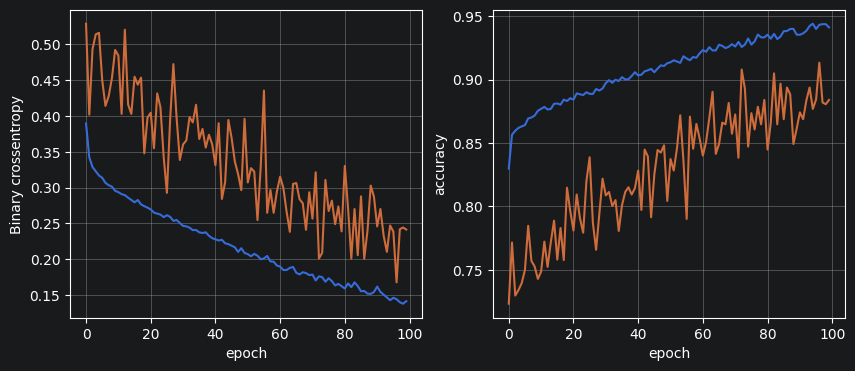

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8638 - loss: 0.5638  
64 nodes, dropout 0, lr 0.005, batch_size 128


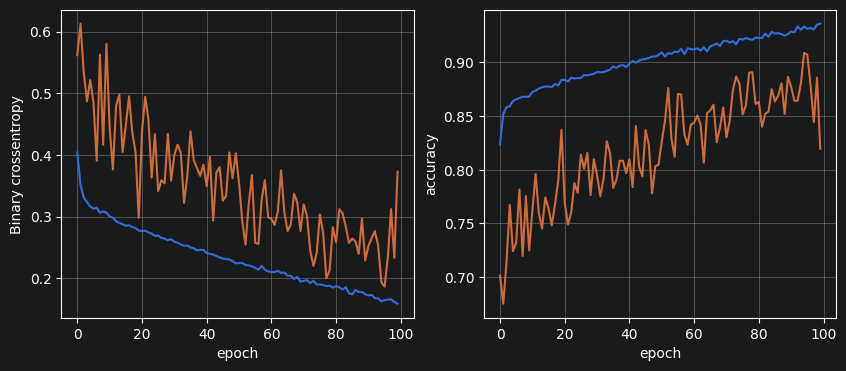

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.8672 - loss: 0.5144
64 nodes, dropout 0, lr 0.001, batch_size 32


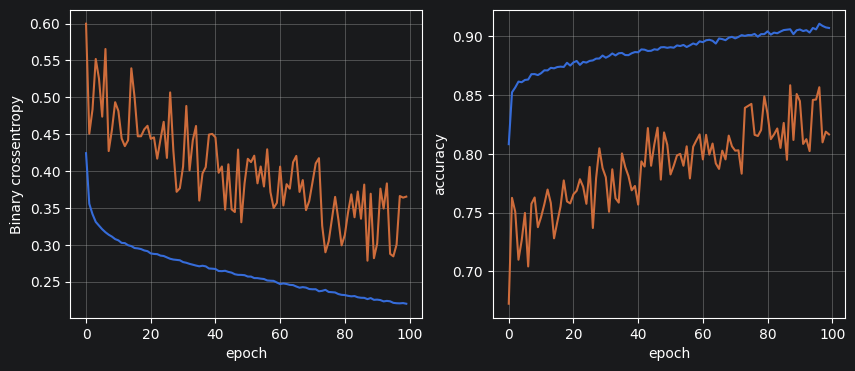

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.8733 - loss: 0.3347
64 nodes, dropout 0, lr 0.001, batch_size 64


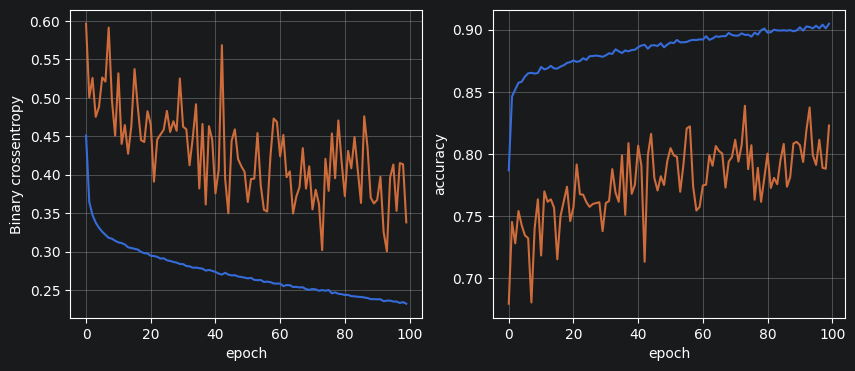

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8722 - loss: 0.3232
64 nodes, dropout 0, lr 0.001, batch_size 128


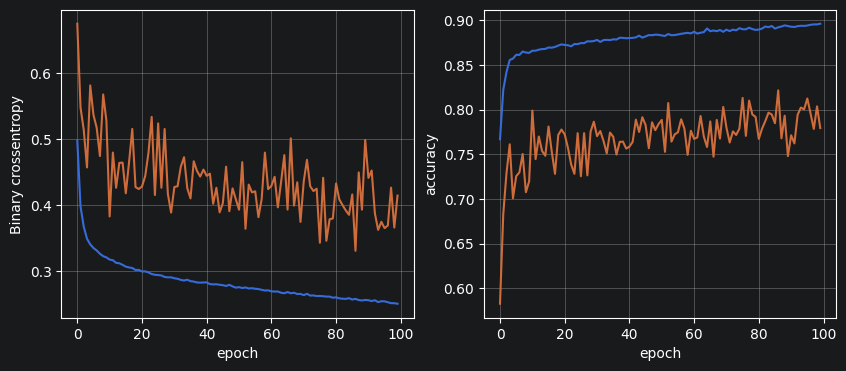

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.8759 - loss: 0.3150
64 nodes, dropout 0.2, lr 0.01, batch_size 32


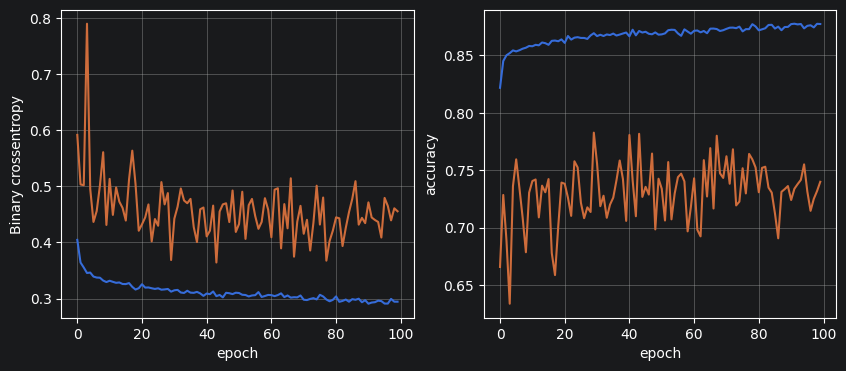

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8712 - loss: 0.3240
64 nodes, dropout 0.2, lr 0.01, batch_size 64


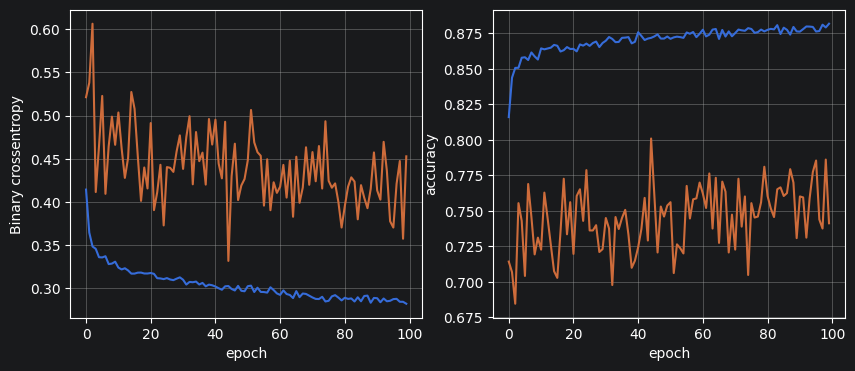

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8743 - loss: 0.3167
64 nodes, dropout 0.2, lr 0.01, batch_size 128


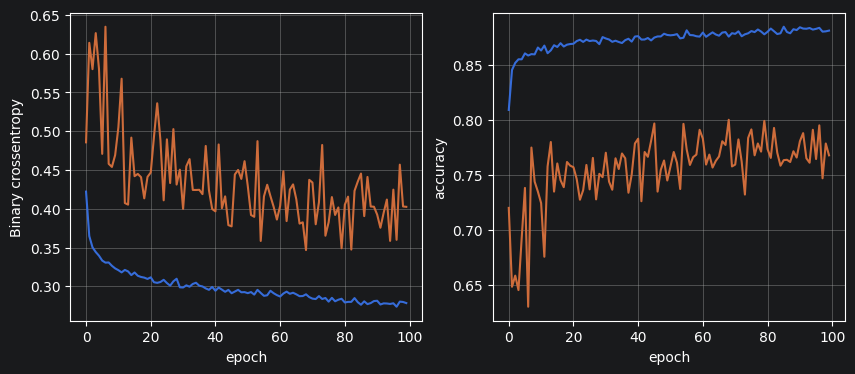

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.8828 - loss: 0.3062
64 nodes, dropout 0.2, lr 0.005, batch_size 32


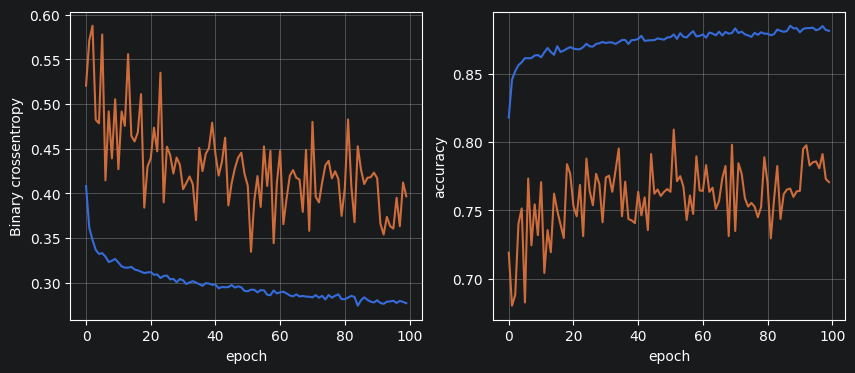

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.8812 - loss: 0.3085
64 nodes, dropout 0.2, lr 0.005, batch_size 64


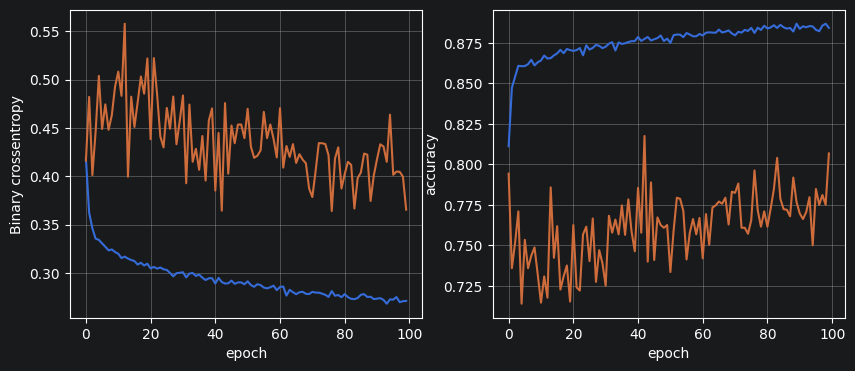

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.8849 - loss: 0.3017
64 nodes, dropout 0.2, lr 0.005, batch_size 128


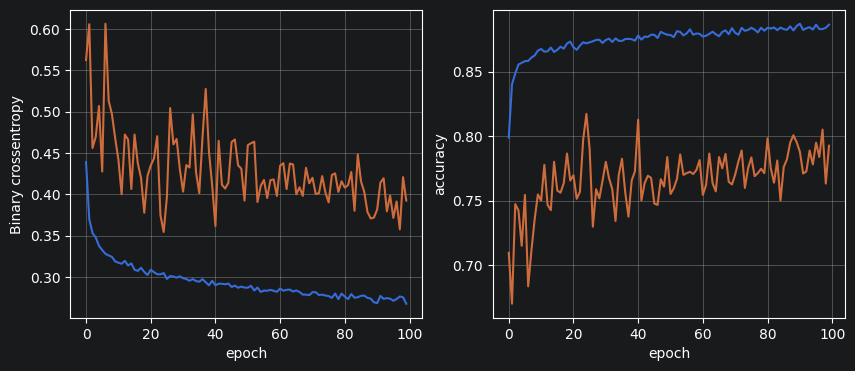

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.8749 - loss: 0.3066
64 nodes, dropout 0.2, lr 0.001, batch_size 32


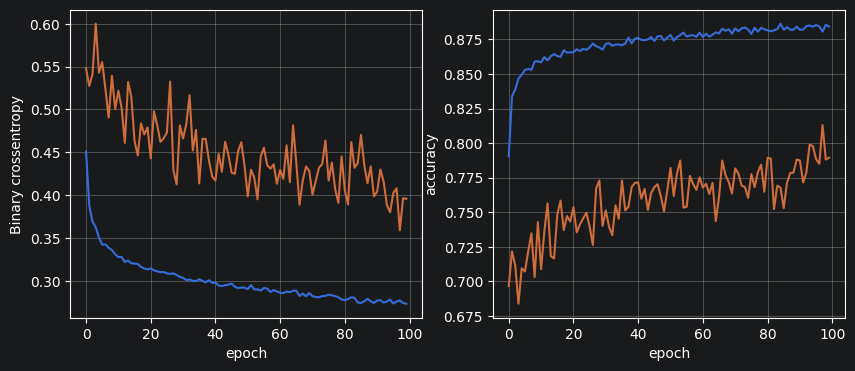

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.8788 - loss: 0.3012
64 nodes, dropout 0.2, lr 0.001, batch_size 64


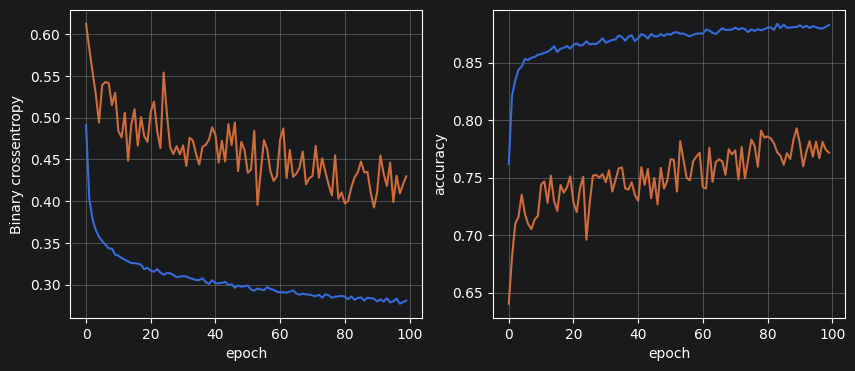

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - accuracy: 0.8788 - loss: 0.2966
64 nodes, dropout 0.2, lr 0.001, batch_size 128


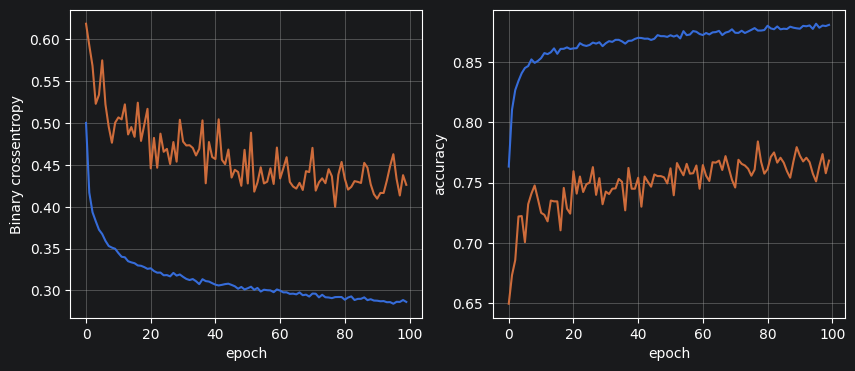

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.8738 - loss: 0.2964


In [42]:
least_val_loss = float('inf')
least_loss_model = None
epochs=100
for num_nodes in [16,23,64]:
    for dropout_prob in[0,0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32,64,128]:
                print(f'{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch_size {batch_size}')
                model, history = train_model(X_train, y_train, num_nodes,dropout_prob,lr,batch_size, epochs)
                plot_history(history)
                val_loss, val_accuracy = model.evaluate(X_valid, y_valid)
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model


In [49]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)
y_pred
print(classification_report(y_test, y_pred))

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1331
           1       0.88      0.94      0.91      2473

    accuracy                           0.87      3804
   macro avg       0.87      0.85      0.86      3804
weighted avg       0.87      0.87      0.87      3804

